In [1]:
import pandas as pd

df = pd.read_csv("MPS_Borough_Level_Crime _Most_Recent_24_months_new.csv")

print(df.shape)
print(df.columns.tolist()[-6:])

(993, 27)
['202601', '202602', '202603', '202604', '202605', '202606']


In [2]:
not_boroughs = ["Unknown", "London Heathrow and London City Airports"]
df_clean = df[~df["BoroughName"].isin(not_boroughs)]

print("Boroughs:", df_clean["BoroughName"].nunique())

new_months = ["202603", "202604", "202605", "202606"]
actual_totals = df_clean[new_months].sum()

print(actual_totals)

KeyError: 'BoroughName'

In [3]:
print(df.columns.tolist())

['Group', 'SubGroup', 'BOCU', '202407', '202408', '202409', '202410', '202411', '202412', '202501', '202502', '202503', '202504', '202505', '202506', '202507', '202508', '202509', '202510', '202511', '202512', '202601', '202602', '202603', '202604', '202605', '202606']


In [4]:
not_boroughs = ["Unknown", "London Heathrow and London City Airports"]
df_clean = df[~df["BOCU"].isin(not_boroughs)]

print("Boroughs:", df_clean["BOCU"].nunique())

new_months = ["202603", "202604", "202605", "202606"]
actual_totals = df_clean[new_months].sum()

print(actual_totals)

Boroughs: 32
202603    75137
202604    73990
202605    78652
202606    79894
dtype: int64


In [5]:
validation = pd.DataFrame({
    "Month": ["2026-03", "2026-04", "2026-05", "2026-06"],
    "Forecast": [73103, 71817, 76096, 75829],
    "Lower_95CI": [64587, 60272, 62131, 59808],
    "Upper_95CI": [81618, 83362, 90061, 91850],
    "Actual": [75137, 73990, 78652, 79894]
})

validation["Error"] = validation["Actual"] - validation["Forecast"]
validation["Pct_Error"] = (validation["Error"].abs() / validation["Actual"] * 100).round(1)
validation["Within_95CI"] = (validation["Actual"] >= validation["Lower_95CI"]) & (validation["Actual"] <= validation["Upper_95CI"])

print(validation.to_string(index=False))

print()
print("Mean absolute error:", validation["Error"].abs().mean().round(0))
print("Mean % error:", validation["Pct_Error"].mean().round(2))
print("All within 95% CI:", validation["Within_95CI"].all())

  Month  Forecast  Lower_95CI  Upper_95CI  Actual  Error  Pct_Error  Within_95CI
2026-03     73103       64587       81618   75137   2034        2.7         True
2026-04     71817       60272       83362   73990   2173        2.9         True
2026-05     76096       62131       90061   78652   2556        3.2         True
2026-06     75829       59808       91850   79894   4065        5.1         True

Mean absolute error: 2707.0
Mean % error: 3.48
All within 95% CI: True


In [7]:
import matplotlib.pyplot as plt

historical = pd.read_csv("MPS_Borough_Level_Crime_Historical.csv")
recent = pd.read_csv("MPS_Borough_Level_Crime_Recent_24_month.csv")

id_cols = ["MajorText", "MinorText", "BoroughName"]
hist_long = historical.melt(id_vars=id_cols, var_name="YearMonth", value_name="CrimeCount")
recent_long = recent.melt(id_vars=id_cols, var_name="YearMonth", value_name="CrimeCount")
crime = pd.concat([hist_long, recent_long], ignore_index=True)

not_boroughs_old = ["Unknown", "London Heathrow and London City Airports"]
crime = crime[~crime["BoroughName"].isin(not_boroughs_old)]
crime["Date"] = pd.to_datetime(crime["YearMonth"], format="%Y%m")

london_monthly = crime.groupby("Date")["CrimeCount"].sum().sort_index()
history = london_monthly[-24:]  # last 24 months for context

print(history.tail())

Date
2025-10-01    76963
2025-11-01    76013
2025-12-01    73393
2026-01-01    70305
2026-02-01    67469
Name: CrimeCount, dtype: int64


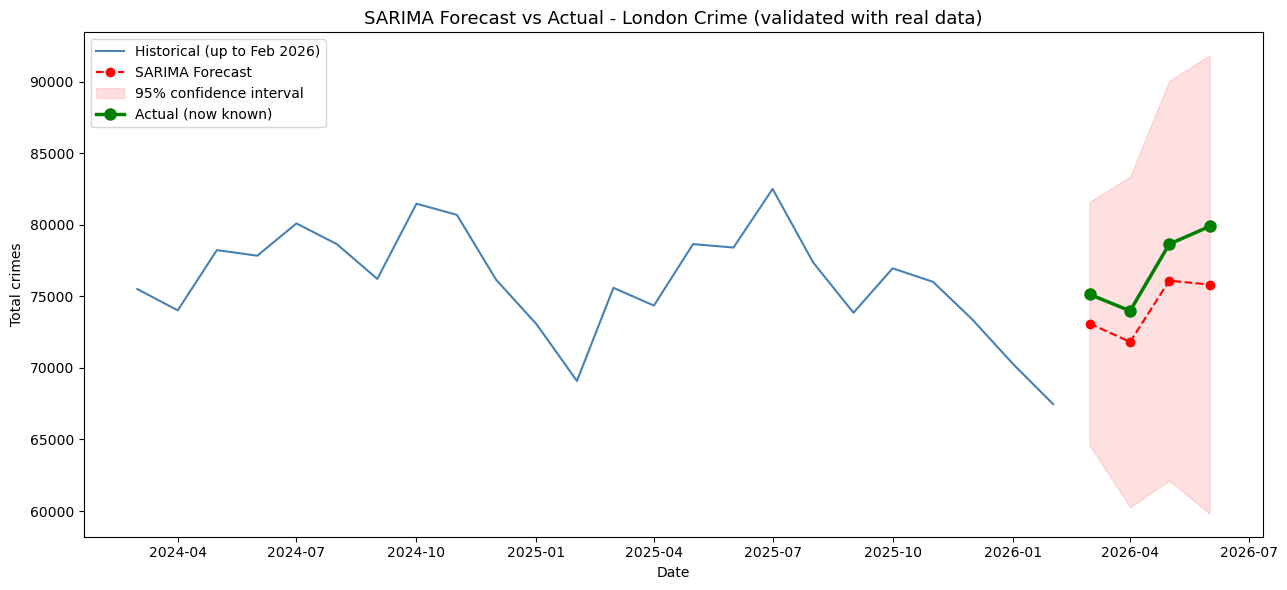

In [8]:
validation["Date"] = pd.to_datetime(validation["Month"], format="%Y-%m")

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(history.index, history.values, label="Historical (up to Feb 2026)", color="steelblue")

ax.plot(validation["Date"], validation["Forecast"], label="SARIMA Forecast",
         color="red", marker="o", linestyle="--")
ax.fill_between(validation["Date"], validation["Lower_95CI"], validation["Upper_95CI"],
                 color="red", alpha=0.12, label="95% confidence interval")

ax.plot(validation["Date"], validation["Actual"], label="Actual (now known)",
         color="green", marker="o", linewidth=2.5, markersize=8)

ax.set_title("SARIMA Forecast vs Actual - London Crime (validated with real data)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Total crimes")
ax.legend()
plt.tight_layout()
plt.savefig("figures/13_forecast_validation.png", dpi=150)
plt.show()

In [9]:
new_months_series = actual_totals.copy()
new_months_series.index = pd.to_datetime(new_months_series.index, format="%Y%m")

full_history = pd.concat([london_monthly, new_months_series]).sort_index()
full_history = full_history[~full_history.index.duplicated(keep="last")]
full_history = full_history.asfreq("MS")

print(full_history.tail(8))
print("Last date:", full_history.index.max().date())

2025-11-01    76013
2025-12-01    73393
2026-01-01    70305
2026-02-01    67469
2026-03-01    75137
2026-04-01    73990
2026-05-01    78652
2026-06-01    79894
Freq: MS, dtype: int64
Last date: 2026-06-01


In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(full_history, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12))
fitted = model.fit(disp=False)

forecast_result = fitted.get_forecast(steps=6)
future_forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

future_table = pd.DataFrame({
    "Forecast": future_forecast.values.round(0),
    "Lower_95CI": conf_int.iloc[:, 0].values.round(0),
    "Upper_95CI": conf_int.iloc[:, 1].values.round(0)
}, index=future_forecast.index)

print(future_table)

            Forecast  Lower_95CI  Upper_95CI
2026-07-01   83515.0     75090.0     91940.0
2026-08-01   79091.0     67665.0     90517.0
2026-09-01   75773.0     61951.0     89595.0
2026-10-01   79285.0     63427.0     95142.0
2026-11-01   78367.0     60707.0     96028.0
2026-12-01   75387.0     56092.0     94682.0


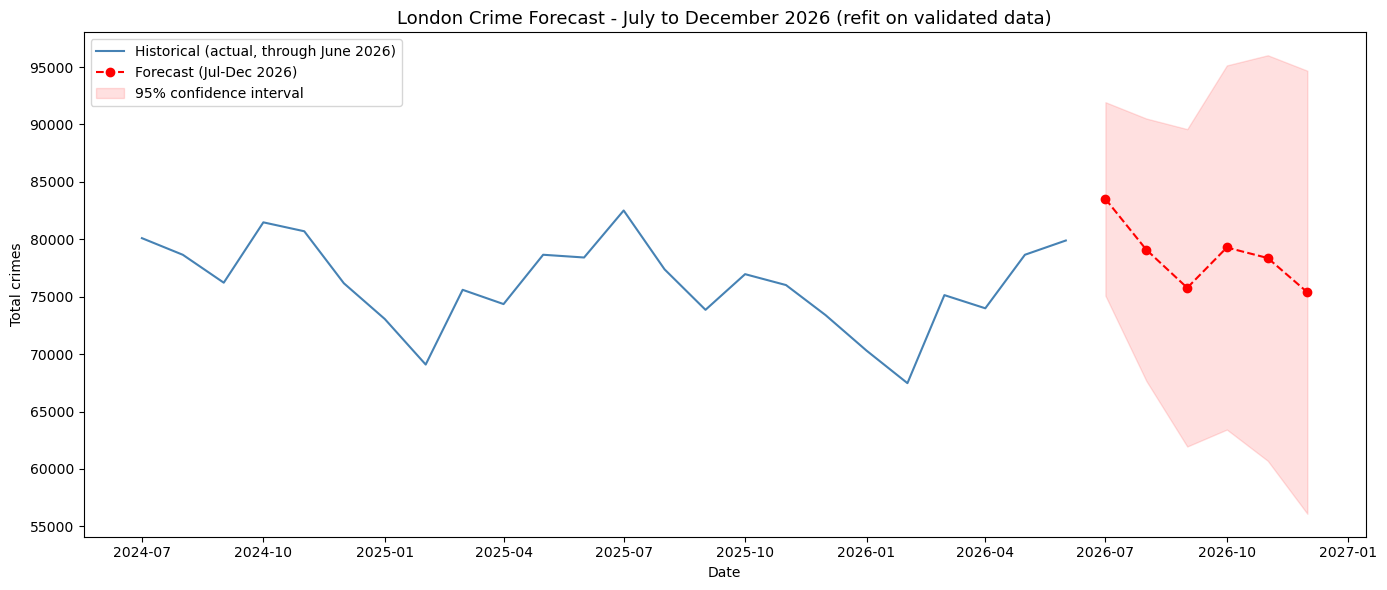

In [11]:
plt.figure(figsize=(14, 6))

recent_history = full_history[-24:]
plt.plot(recent_history.index, recent_history.values, label="Historical (actual, through June 2026)", color="steelblue")

plt.plot(future_table.index, future_table["Forecast"], label="Forecast (Jul-Dec 2026)",
          color="red", marker="o", linestyle="--")
plt.fill_between(future_table.index, future_table["Lower_95CI"], future_table["Upper_95CI"],
                   color="red", alpha=0.12, label="95% confidence interval")

plt.title("London Crime Forecast - July to December 2026 (refit on validated data)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Total crimes")
plt.legend()
plt.tight_layout()
plt.savefig("figures/14_future_forecast_updated.png", dpi=150)
plt.show()